# Multi-objective optimization of the Viennet function with MOSA

This notebook minimizes the three-objective Viennet test function with the `mosa` implementation of Multi-Objective Simulated Annealing (MOSA). The function and search domain follow the [Wikipedia test-functions page](https://en.wikipedia.org/wiki/Test_functions_for_optimization#Test_functions_for_multi-objective_optimization):

$$f_1(x,y)=\tfrac{1}{2}(x^2+y^2)+\sin(x^2+y^2),$$

$$f_2(x,y)=\frac{(3x-2y+4)^2}{8}+\frac{(x-y+1)^2}{27}+15,$$

$$f_3(x,y)=\frac{1}{x^2+y^2+1}-1.1\exp[-(x^2+y^2)],$$

with $-3 \le x,y \le 3$. All three objectives are minimized. Because their optima conflict, the result is a nondominated archive (an approximation to the Pareto front), not a single universal optimum.

This notebook was created by [OpenAi Codex](https://openai.com/codex/) coding agent using `mosa-optimize` skill with the following prompt:

> Create a documented Jupyter notebook using MOSA to implement the optimization of Viennet
> function as described in [Test functions for optimization](https://en.wikipedia.org/wiki/Test_functions_for_optimization)
> in Wikipedia. Use automatic temperature. Number of temperatures must be 100 and 200 iterations
> per temperature. Maximum step lenght is 0.5 and adaptive step length must be used. Temperature
> decrease factor is 0.95. Plot the objective values.


## Imports and reproducibility

MOSA 1.2.0 was available when this notebook was created. The random seed makes this run reproducible for the same package and dependency versions.

In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import numpy as np
from mosa import Anneal

np.random.seed(42)

## Objective function

`mosa.Anneal` minimizes every returned component, so the function returns the three values as a fixed-length tuple. The argument names match the population group names configured below.

In [2]:
def viennet(x, y):
    """Return the three Viennet objectives for scalar decision variables x and y."""
    radius_squared = x**2 + y**2
    f1 = 0.5 * radius_squared + np.sin(radius_squared)
    f2 = ((3.0 * x - 2.0 * y + 4.0) ** 2) / 8.0 + ((x - y + 1.0) ** 2) / 27.0 + 15.0
    f3 = 1.0 / (radius_squared + 1.0) - 1.1 * np.exp(-radius_squared)
    return f1, f2, f3


# A quick check at the origin.
assert np.allclose(viennet(0.0, 0.0), (0.0, 17.037037037037038, -0.1))
viennet(0.0, 0.0)

(np.float64(0.0), 17.037037037037038, np.float64(-0.10000000000000009))

## MOSA configuration

The requested settings are applied directly:

- automatic initial-temperature calibration (`initial_temperature` is deliberately left as `None`);
- 100 temperatures and 200 Monte Carlo iterations per temperature;
- temperature decrease factor 0.95;
- initial maximum step length 0.5 for both continuous variables;
- Corana adaptive step-length control (`adaptative_mc_step`, using MOSA's API spelling).

Restarting is disabled so this is an independent run. MOSA always writes its archive, so a temporary directory avoids leaving a stale archive that could affect later executions. Optimization-progress tracking retains accepted objective triples for the plots.

In [3]:
optimizer = Anneal()
optimizer.set_population(x=(-3.0, 3.0), y=(-3.0, 3.0))
optimizer.set_opt_param("mc_step_size", x=0.5, y=0.5)

optimizer.restart = False
optimizer.archive_save_interval = 0
optimizer.auto_high_temperature = True
optimizer.number_of_temperatures = 100
optimizer.number_of_iterations = 200
optimizer.temperature_decrease_factor = 0.95
optimizer.adaptative_mc_step = True
optimizer.track_optimization_progress = True

assert optimizer.initial_temperature is None
assert optimizer.mc_step_size == {"x": 0.5, "y": 0.5}

with TemporaryDirectory() as temporary_directory:
    optimizer.archive_file = str(Path(temporary_directory) / "viennet_archive.json")
    optimizer.evolve(viennet)
    archive = optimizer.copyx()

objective_values = np.asarray(archive["f"], dtype=float)
decision_values = np.asarray(
    [[solution["x"], solution["y"]] for solution in archive["x"]],
    dtype=float,
)

print(f"Nondominated solutions retained: {len(objective_values)}")
print("Objective-wise minima in the retained archive:", objective_values.min(axis=0))
print("Objective-wise maxima in the retained archive:", objective_values.max(axis=0))

--------------------------------------------------
 MULTI-OBJECTIVE SIMULATED ANNEALING (MOSA) 1.2.5  
--------------------------------------------------
--- BEGIN: Evolving a solution ---

Initializing an empty archive...
Done!
------

Groups in the solution:

    x:
        Number of elements: 1
        Sample space: continuous
        Boundaries: (-3.0,3.0)
        Selection probability: 0.500000
        Trial move probabilities:
            Change value: 1.0
        Sort values: False
        Maximum step size: 0.5
    y:
        Number of elements: 1
        Sample space: continuous
        Boundaries: (-3.0,3.0)
        Selection probability: 0.500000
        Trial move probabilities:
            Change value: 1.0
        Sort values: False
        Maximum step size: 0.5
------
Initializing with a random solution from scratch...
Done!
------
Estimating initial high-temperature...
Done!
------
Starting at temperature: 10.000000
Evolving solutions to the problem, please wait...
Max

## Objective values in the nondominated archive

Each point is a retained nondominated solution. The 3D view shows the joint trade-off among all objectives; the pairwise projections make dense regions easier to inspect. Objective-wise minima printed above generally belong to different solutions and therefore should not be interpreted as a simultaneously attainable objective vector.

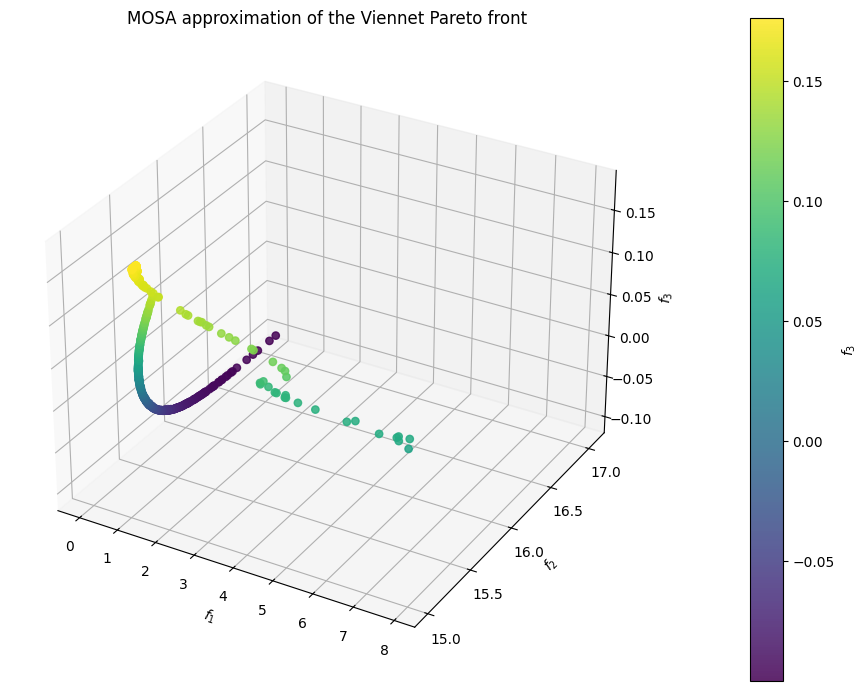

In [4]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
points = ax.scatter(
    objective_values[:, 0],
    objective_values[:, 1],
    objective_values[:, 2],
    c=objective_values[:, 2],
    cmap="viridis",
    s=28,
    alpha=0.85,
)
ax.set(
    xlabel="$f_1$",
    ylabel="$f_2$",
    zlabel="$f_3$",
    title="MOSA approximation of the Viennet Pareto front",
)
fig.colorbar(points, ax=ax, pad=0.12, label="$f_3$")
plt.tight_layout()
plt.show()

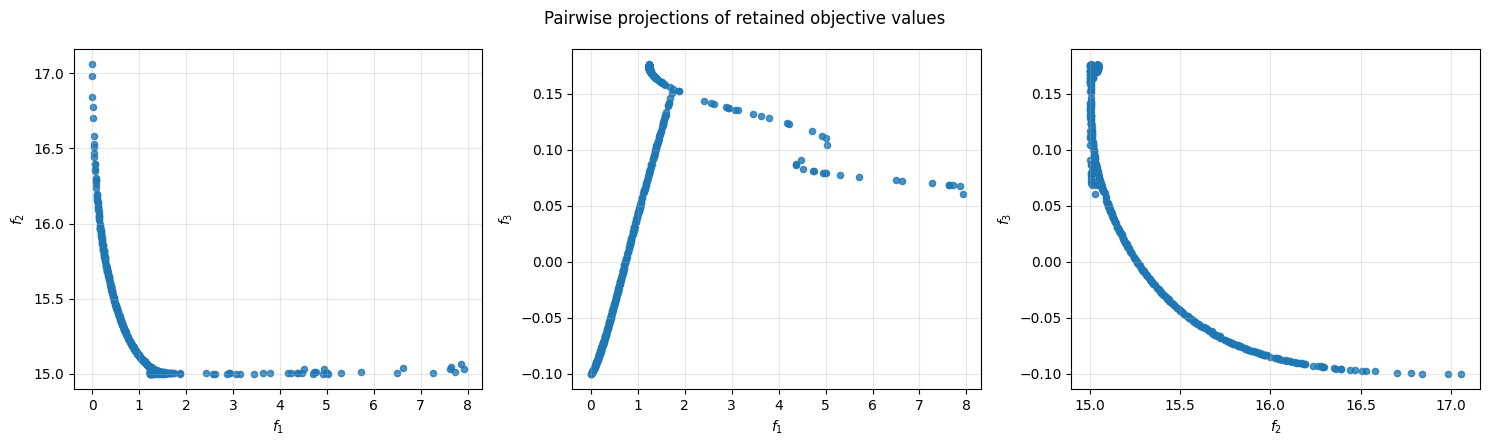

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
pairs = ((0, 1), (0, 2), (1, 2))
for ax, (i, j) in zip(axes, pairs):
    ax.scatter(objective_values[:, i], objective_values[:, j], s=20, alpha=0.8)
    ax.set(xlabel=f"$f_{i + 1}$", ylabel=f"$f_{j + 1}$")
    ax.grid(alpha=0.3)
fig.suptitle("Pairwise projections of retained objective values")
fig.tight_layout()
plt.show()

## Accepted objective values during annealing

These traces show objective values for accepted moves. They are diagnostics of the stochastic search, not monotone convergence curves: MOSA intentionally accepts some worsening moves and must balance three competing objectives.

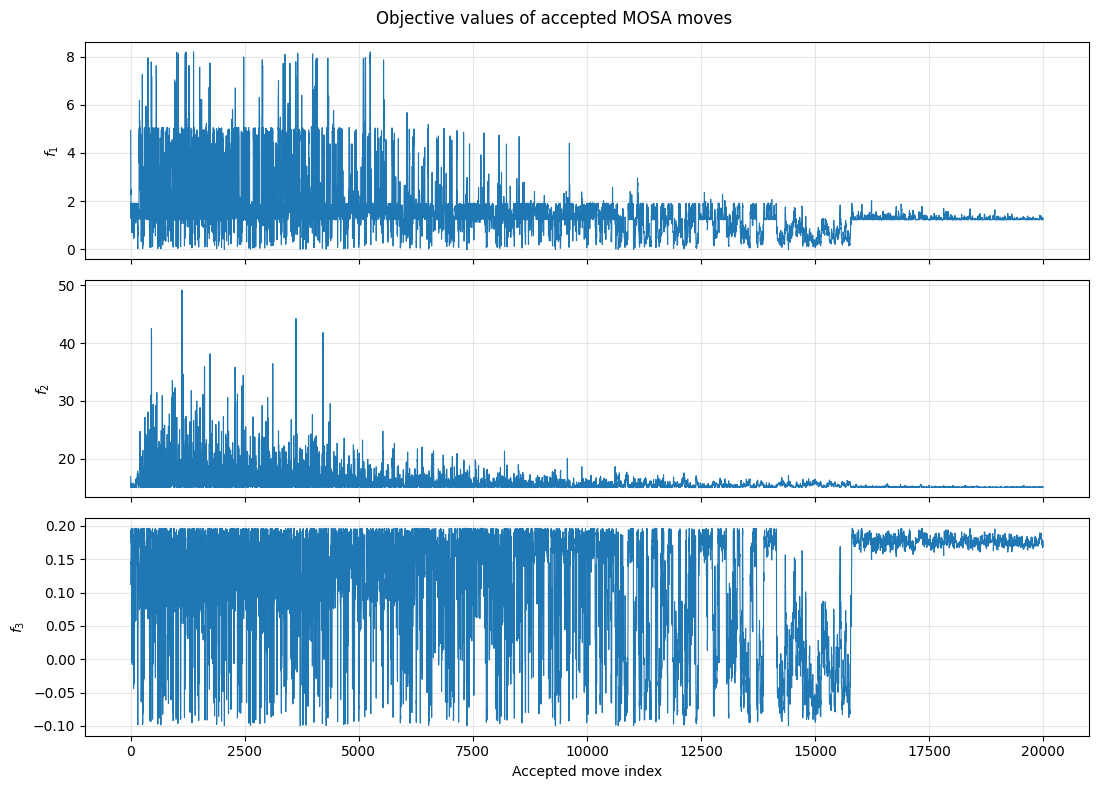

In [6]:
accepted = np.asarray(optimizer.accepted_objective_values, dtype=float)
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for index, ax in enumerate(axes):
    ax.plot(accepted[:, index], linewidth=0.8)
    ax.set_ylabel(f"$f_{index + 1}$")
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("Accepted move index")
fig.suptitle("Objective values of accepted MOSA moves")
fig.tight_layout()
plt.show()